# Create a dataset with the Statistical factor model, top factor returns and residualized returns

We have $R\in\mathbb{R}^{n\times T}$ and want:

$$ R = BF + \epsilon$$

where $R\in\mathbb{R}^{n\times p}$ and $F\in\mathbb{R}^{p\times T}$, B is going to be the rolling columns of eigenvectors and $F$ will represent the statistical factor returns.

And $\epsilon\in\mathbb{R}^{n\times T}$ are the residualized returns.


In [20]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
pd.set_option("display.max_columns",100)

returns = pd.read_hdf("Data/daily_returns_SPX.h5")
returns = returns.apply(pd.to_numeric)
returns.head(2)

,A,AAPL,ABBV,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,ADSK,AEE,AES,AFL,AIG,AIZ,AJG,AKAM,ALB,ALGN,ALL,ALLE,AMAT,AMD,AME,AMGN,AMP,AMT,AMZN,ANET,AON,AOS,APD,APH,APO,APTV,ARE,ARES,ATO,AVB,AVGO,AVY,AWK,AXP,AZO,BA,BAC,BALL,BAX,BBY,...,TRGP,TRMB,TROW,TRV,TSCO,TSLA,TSN,TT,TTWO,TXN,TXT,TYL,UDR,UHS,ULTA,UNH,UNP,UPS,URI,USB,V,VLO,VMC,VRSK,VRSN,VRTX,VTR,VTRS,VZ,WAB,WAT,WDC,WEC,WELL,WFC,WM,WMB,WRB,WSM,WST,WTW,WY,WYNN,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2016-03-09,0.001050,0.000891,0.019342,0.002808,-0.001161,0.007601,0.010907,-0.007409,0.000833,0.008890,-0.002990,0.008777,-0.011299,0.006161,-0.006547,0.018745,0.005137,0.011176,0.030096,0.001275,-0.000774,0.005878,0.020767,-0.017391,-0.001676,-0.025790,-0.001801,0.000000,-0.001410,0.030058,0.002844,-0.009684,0.003427,0.001796,0.000595,0.002466,0.006861,0.059495,0.001837,0.006133,0.016687,0.013494,0.004680,-0.006394,0.014692,0.004168,0.006126,0.001187,0.000253,0.002938,...,0.048429,0.012987,-0.006253,0.004330,0.010591,0.030207,0.009780,0.007517,0.009852,0.004034,0.020609,-0.000745,0.011023,0.010642,-0.024239,-0.000493,0.024153,-0.010535,0.024631,-0.002258,0.000850,0.039628,0.004210,0.010972,-0.001722,-0.026234,0.005846,0.040223,-0.002287,0.002657,0.001331,0.021533,0.005366,0.009718,-0.005301,0.005932,0.040556,-0.005714,-0.010807,0.003441,-0.001885,0.002910,0.016071,-0.002783,0.006331,0.047909,-0.004956,-0.001691,0.024555,0.005717
2016-03-10,-0.003934,0.000494,-0.002837,-0.006365,0.001017,0.001741,-0.004926,0.003459,-0.008042,-0.006066,-0.013053,-0.006837,0.029524,-0.000993,0.005234,0.001957,0.010221,-0.009966,-0.014276,-0.003819,-0.004184,-0.003474,0.020866,0.000000,-0.005247,0.000923,-0.002256,0.001163,-0.000965,-0.041261,-0.001621,0.011155,-0.000594,-0.006454,-0.000595,-0.010708,0.003706,0.039231,0.000282,-0.005597,0.017329,0.007670,-0.006697,-0.005080,0.015548,0.000651,0.009893,-0.004741,0.005304,0.006444,...,-0.037729,-0.012420,-0.002936,0.001796,0.023149,-0.016961,0.008475,0.001745,0.019225,0.013516,-0.006031,-0.008536,-0.002237,-0.000531,0.027545,0.008175,-0.009483,0.003114,-0.005495,-0.006288,-0.006508,-0.009568,0.006435,-0.009676,0.002530,-0.027768,0.008806,0.015897,-0.000382,-0.004373,-0.003361,0.009486,-0.002755,-0.020602,-0.005739,0.000173,-0.079621,0.000575,0.020264,-0.004208,0.002833,0.017773,0.030652,-0.002670,-0.006029,-0.060682,0.006029,0.004782,-0.013827,-0.013594


In [2]:
rolling_window = 750
pca_model = PCA(n_components=20).fit(returns.values)

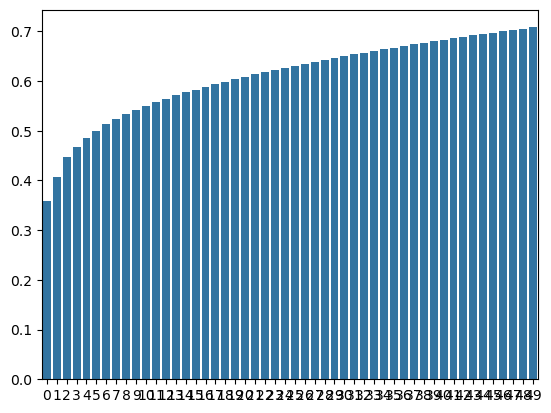

In [3]:
returns_trains = returns.iloc[:rolling_window,:]
pca_model_benchmark1 = PCA().fit(returns.values)
import matplotlib.pyplot as plt
import seaborn as sns
ax = sns.barplot(data = pca_model_benchmark1.explained_variance_ratio_.cumsum()[:50])


- Time-dimension reweighting: First step is to estimate idio volatilities with the following half-life:

$$\tau_f = 56 days$$

In [4]:
idio_half_life = 56
window_idio = 4*idio_half_life
idio_tau = idio_half_life/np.log(2)
# Constant st the sum of square sum to the window length
kappa_idio = np.sqrt(window_idio*(1-np.exp(-2/idio_tau))/(1-np.exp(-2*window_idio/idio_tau)))
weigths_idio = kappa_idio * np.exp(-np.arange(window_idio)/idio_tau)
weigths_idio_matrix = np.diag(weigths_idio)

In [5]:
return_window = returns.iloc[:window_idio,:].T
idio_return_window_scaled = return_window.values @ weigths_idio_matrix
n_idio_factors = 10
print("Shape of the first return window:", idio_return_window_scaled.shape)

from scipy.linalg import svd
from scipy.sparse.linalg import svds

U,S,V_t = svds(idio_return_window_scaled,k = n_idio_factors)
U1,S1,V_t1 = svd(idio_return_window_scaled)


Shape of the first return window: (428, 224)


In [6]:
# Reorder the eigenvalues from the biggest to smallest
idx1 = np.argsort(S)[::-1]
U, S, V_t = U[:,idx1], S[idx1], V_t[idx1,:]
var_explained = np.sum(S**2)/np.sum(S1**2)
print(f"Variance explained by the {n_idio_factors} is {100*var_explained:.3f}%")
residuals1 = idio_return_window_scaled - U @ np.diag(S) @ V_t
idio_vols = np.mean(residuals1**2, axis = 1)
print("shapes:",residuals1.shape, idio_vols.shape)
# print(np.mean(idio_return_window_scaled**2,axis = 1)[:5]) check that idio vol is smaller than total vol
# print(idio_vols[:5])
weight_vols_matrix = np.diag(1/idio_vols)

Variance explained by the 10 is 60.676%
shapes: (428, 224) (428,)


In [7]:
corr_half_life = 200
window_corr = 4*corr_half_life
corr_tau = corr_half_life/np.log(2)
# Constant st the sum of square sum to the window length
kappa_corr = np.sqrt(window_corr*(1-np.exp(-2/corr_tau))/(1-np.exp(-2*window_corr/corr_tau)))
weigths_corr = kappa_corr * np.exp(-np.arange(window_corr)/corr_tau)
weigths_corr_matrix = np.diag(weigths_corr)

In [8]:
return_window_corr = returns.iloc[:window_corr,:].T
return_window_corr_scaled =  weight_vols_matrix @ return_window_corr.values @ weigths_corr_matrix
print("Shape of the rescaled returns:",return_window_corr_scaled.shape)
n_pca_factors = 10
U_f,S_f,V_tf = svds(return_window_corr_scaled,k = n_pca_factors)
idx2 = np.argsort(S_f)[::-1]
U_f, S_f, V_tf = U_f[:,idx2], S_f[idx2], V_tf[idx2,:]
U_tot,S_tot,V_t_tot = svd(return_window_corr_scaled)
var_explained1 = np.sum(S_f**2)/np.sum(S_tot**2)
print(f"We explain {100*var_explained1:.3f}% of the variance using {n_pca_factors}")

Shape of the rescaled returns: (428, 800)
We explain 63.849% of the variance using 10


In [9]:
print(U_f.shape, S_f.shape, V_tf.shape)
B = np.diag(idio_vols) @ U_f
f = np.diag(S_f) @ V_tf @ np.diag(1/weigths_corr)
print("Shapes:", B.shape, f.shape)

(428, 10) (10,) (10, 800)
Shapes: (428, 10) (10, 800)


In [10]:
f1 = U_f.T @ np.diag(1/idio_vols) @ return_window_corr.values
print(np.all(np.isclose(f,f1)))

True


- But to have $\alpha$-ready residuals we need to compute them with next unknown return based on the model known at time $t$:

$$\hat{f}_t = \hat{U}_{t-1}^T W_{\sigma,t-1} r_t = (B_{t-1}^TW_{\sigma,t-1}^2 B_{t-1})^{-1} B_{t-1}^T W_{\sigma,t-1}^2 r_t$$

and

$$\hat{\epsilon}_t = r_t - B_{t-1}\hat{f}_t$$

where $B_{t-1} =W_{\sigma,t-1}^{-1} \hat{U}_{t-1}$


In [11]:
# So we will compute it that way in our future time for loop:
next_returns_window = returns.iloc[1:window_corr+1,:].T
f_hat = U_f.T @ np.diag(1/idio_vols) @ next_returns_window.values
eps_hat = next_returns_window.values - B @ f_hat

In [12]:
print(f_hat.shape, eps_hat.shape)
eps_t = eps_hat[:,-1]
f_t = f_hat[:,-1]

(10, 800) (428, 800)


# Now let's write the clean for loop that compute the factors/residuals returns without look-ahead bias for alpha models: 

In [13]:
def estimate_current_idio_vols(returns, t, idio_half_life = 56, window_idio = 224,n_idio_factors = 10):
    assert window_idio-1 <= t < returns.shape[0]
    idio_tau = idio_half_life/np.log(2)
    kappa_idio = np.sqrt(window_idio*(1-np.exp(-2/idio_tau))/(1-np.exp(-2*window_idio/idio_tau)))
    weigths_idio = kappa_idio * np.exp(-np.arange(window_idio)/idio_tau)
    weigths_idio_matrix = np.diag(weigths_idio)
    return_window = returns.iloc[t-window_idio+1:t+1,:].T
    idio_return_window_scaled = return_window.values @ weigths_idio_matrix
    U,S,V_t = svds(idio_return_window_scaled,k = n_idio_factors)
    idx1 = np.argsort(S)[::-1]
    U, S, V_t = U[:,idx1], S[idx1], V_t[idx1,:]
    residuals1 = idio_return_window_scaled - U @ np.diag(S) @ V_t
    idio_vols = np.mean(residuals1**2, axis = 1)
    return idio_vols

idio_vols1 = estimate_current_idio_vols(returns, 223)
# print(np.all(np.isclose(idio_vols1,idio_vols))) test
import numpy as np
from scipy.sparse.linalg import svds

def sort_svd(U, S, Vt):
    idx = np.argsort(S)[::-1]
    return U[:, idx], S[idx], Vt[idx, :]


def orient_svd_deterministic(U, Vt):
    """
    Used for the first date when there is no previous U.
    Makes the largest absolute loading in each eigenvector positive.
    """
    U = U.copy()
    Vt = Vt.copy()

    for j in range(U.shape[1]):
        anchor = np.argmax(np.abs(U[:, j]))
        if U[anchor, j] < 0:
            U[:, j] *= -1
            Vt[j, :] *= -1

    return U, Vt


def align_svd_to_previous(U, Vt, U_prev=None):
    """
    Align signs of current U to previous U.
    """
    U = U.copy()
    Vt = Vt.copy()

    if U_prev is None:
        return orient_svd_deterministic(U, Vt)

    for j in range(U.shape[1]):
        if np.dot(U[:, j], U_prev[:, j]) < 0:
            U[:, j] *= -1
            Vt[j, :] *= -1

    return U, Vt

def estimate_current_model(returns, t,  idio_vols, corr_half_life = 200, window_corr = 800, n_pca_factors = 10):
    # Returns B_t and f_t
    assert window_corr-1 <= t < returns.shape[0]-1
    weight_vols_matrix = np.diag(1/idio_vols)
    corr_tau = corr_half_life/np.log(2)
    kappa_corr = np.sqrt(window_corr*(1-np.exp(-2/corr_tau))/(1-np.exp(-2*window_corr/corr_tau)))
    weigths_corr = kappa_corr * np.exp(-np.arange(window_corr)/corr_tau)
    weigths_corr_matrix = np.diag(weigths_corr)
    return_window_corr = returns.iloc[t-window_corr+1:t+1,:].T
    return_window_corr_scaled =  weight_vols_matrix @ return_window_corr.values @ weigths_corr_matrix
    U_f,S_f,V_tf = svds(return_window_corr_scaled,k = n_pca_factors)
    idx2 = np.argsort(S_f)[::-1]
    U_f, S_f, V_tf = U_f[:,idx2], S_f[idx2], V_tf[idx2,:]
    B_t = np.diag(idio_vols) @ U_f
    next_returns_window = returns.iloc[t-window_corr+2:t+2,:].T
    f_t = U_f.T @ np.diag(1/idio_vols) @ next_returns_window.values
    return B_t,f_t

B_1,f_1 = estimate_current_model(returns, 799,  idio_vols1, corr_half_life = 200, window_corr = 800, n_pca_factors = 10)

In [14]:
B_t1 = B_1[:,-1]
f_t1 = f_1[:,-1]
print(np.all(np.isclose(B[:,-1],B_t1)),np.all(np.isclose(f_t1,f_t)))

True False


In [37]:
def estimate_current_model(
    returns,
    t,
    idio_vols,
    U_prev=None,
    corr_half_life=200,
    window_corr=800,
    n_pca_factors=10
):
    assert window_corr - 1 <= t < returns.shape[0] - 1

    W_sigma = np.diag(1 / idio_vols)

    corr_tau = corr_half_life / np.log(2)
    kappa_corr = np.sqrt(
        window_corr
        * (1 - np.exp(-2 / corr_tau))
        / (1 - np.exp(-2 * window_corr / corr_tau))
    )

    weights_corr = kappa_corr * np.exp(-np.arange(window_corr)[::-1] / corr_tau)
    W_time = np.diag(weights_corr)

    R_window = returns.iloc[t-window_corr+1:t+1, :].T.values

    R_scaled = W_sigma @ R_window @ W_time

    U_f, S_f, V_tf = svds(R_scaled, k=n_pca_factors)

    # Important: sort first
    U_f, S_f, V_tf = sort_svd(U_f, S_f, V_tf)

    # Then fix sign
    U_f, V_tf = align_svd_to_previous(U_f, V_tf, U_prev)

    # Raw-return loadings
    B_t = np.diag(idio_vols) @ U_f

    # Compute realized factor returns using unweighted scaled returns
    next_returns_window = returns.iloc[t-window_corr+2:t+2, :].T.values
    next_return = next_returns_window[:,-1] 
    X_next = W_sigma @ next_returns_window
    f_t = U_f.T @ X_next

    resid = next_return - B_t @ f_t[:,-1]

    return B_t, f_t[:,-1], U_f, S_f, resid

In [ ]:
B_1,f_1, U_f, S_f, resid = estimate_current_model(returns, 799,  idio_vols1)
B_t = np.diag(idio_vols1) @ U_f

In [58]:
print(np.sum(U_f[:,1]**2))
print(np.sum(B_t[:,0]**2))
# print(idio_vols1)


0.9999999999999986
5.621581398821241e-09


In [49]:
from tqdm import tqdm
U_prev = None
resid = None
f_t = None
models = {}

for t in tqdm(range(799, returns.shape[0] - 1)):
    idio_vols_t = estimate_current_idio_vols(returns, t)

    models[t] = {"resid" : resid} # Resid at time t is computed at the previous time
    models[t]["f_t"] = f_t

    B_t, f_t, U_t, S_t, resid = estimate_current_model(
        returns,
        t,
        idio_vols_t,
        U_prev=U_prev,
        corr_half_life=200,
        window_corr=800,
        n_pca_factors=10
    )
    models[t]["B"] = B_t

    U_prev = U_t

100%|██████████| 1714/1714 [00:52<00:00, 32.66it/s]


In [55]:
ex = models[800]
B_t = models[799]["B"]
f_t = ex["f_t"]
resid = ex["resid"]

In [61]:
# print(np.sum(B[:,0]))
# print(f_t, B[0,:])
r_factor = np.dot(f_t, B_t[0,:])
r_tot = returns.iloc[800,0]
print(r_factor, resid[0],"R_tot:" ,r_tot, "Sum : ", r_factor +  resid[0])
B.shape, f_t.shape


0.010739880618432568 0.01864798538156743 R_tot: 0.029387866 Sum :  0.029387866


((428, 10), (10,))

In [46]:
len(models)

1714

In [19]:
returns.shape[0] - window_corr 

1714